# Assignment 2: Neural Network from Scratch for Multiclass Classification

Use the following fixed architecture:

\[
784 --> 256 --> 128 --> 10
\]

Required training methods:
- Gradient Descent (GD)
- Stochastic Gradient Descent (SGD)
- Mini-batch SGD

Complete all sections marked with **TODO**.

In [50]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [51]:
from google.colab import drive
drive.mount('/content/drive/')
DATA_DIR = "/content/drive/MyDrive/Fashion-Mnist_Dataset" # This was changed for my Google Drive link.

TRAIN_FILE = os.path.join(DATA_DIR, "fashion-mnist_train.csv")
TEST_FILE = os.path.join(DATA_DIR, "fashion-mnist_test.csv")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

INPUT_SIZE = 784
HIDDEN1_SIZE = 256
HIDDEN2_SIZE = 128
OUTPUT_SIZE = 10

VAL_SIZE = 10000

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [52]:
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (60000, 785)
Test shape : (10000, 785)


In [53]:
X_all = train_df.iloc[:, 1:].values.astype(np.float64)
y_all = train_df.iloc[:, 0].values.astype(int)

X_test = test_df.iloc[:, 1:].values.astype(np.float64)
y_test = test_df.iloc[:, 0].values.astype(int)

X_all = X_all / 255.0
X_test = X_test / 255.0

indices = np.arange(X_all.shape[0])
np.random.shuffle(indices)

X_all = X_all[indices]
y_all = y_all[indices]

X_val = X_all[:VAL_SIZE]
y_val = y_all[:VAL_SIZE]

X_train = X_all[VAL_SIZE:]
y_train = y_all[VAL_SIZE:]

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (50000, 784)
X_val  : (10000, 784)
X_test : (10000, 784)


In [54]:
# FINISHED:
# Complete the one-hot encoding function.
#
# Requirements:
# - Input:
#   y           : 1D NumPy array of class labels with shape (n_samples,)
#   num_classes : total number of classes
#
# - Output:
#   Y : 2D NumPy array of shape (n_samples, num_classes)
#       Each row should contain all zeros except one 1 at the correct class index.
#
# Example:
# y = [2, 0, 1], num_classes = 4
# Y should be:
# [[0, 0, 1, 0],
#  [1, 0, 0, 0],
#  [0, 1, 0, 0]]
def one_hot_encode(y, num_classes):    
    Y = []
    for idx in y:
        temp = []
        for _ in range(num_classes):
            temp.append(0) 
        temp[idx] = 1
        Y.append(temp)
    return np.array(Y)

Y_train = one_hot_encode(y_train, OUTPUT_SIZE)
Y_val = one_hot_encode(y_val, OUTPUT_SIZE)
Y_test = one_hot_encode(y_test, OUTPUT_SIZE)


In [55]:
# FINISHED:
# Complete the following helper functions.
#
# 1) relu(Z)
#    Input:
#       Z : 2D NumPy array of any shape
#    Output:
#       elementwise max(0, Z)
#
# 2) relu_derivative(Z)
#    Input:
#       Z : pre-activation values
#    Output:
#       array of the same shape as Z
#       Use 1 where Z > 0, and 0 otherwise
#
# 3) softmax(Z)
#    Input:
#       Z : 2D NumPy array of shape (n_samples, n_classes)
#    Output:
#       probabilities of the same shape
#       Each row should sum to 1
#    Hint:
#       For numerical stability, subtract the row-wise maximum before exponentiating.
#
# 4) compute_loss(Y_true, Y_pred)
#    Input:
#       Y_true : one-hot encoded true labels, shape (n_samples, n_classes)
#       Y_pred : predicted probabilities, shape (n_samples, n_classes)
#    Output:
#       scalar cross-entropy loss averaged over all samples
#    Hint:
#       Use a small epsilon before log to avoid log(0).

def relu(Z):
    Z = np.maximum(0, Z)
    return Z

def relu_derivative(Z):
    Z = np.where(Z > 0, 1, 0)
    return Z

def softmax(Z):
    row_wise_max = Z.max(axis = 1, keepdims = True)
    Z -= row_wise_max
    eZ = np.e ** Z
    return eZ / eZ.sum(axis = 1, keepdims = True)

def compute_loss(Y_true, Y_pred):
    epsilon = 0.00000001
    all_losses = -np.sum(Y_true * np.log(Y_pred + epsilon), axis = 1)
    return np.mean(all_losses)


In [56]:
# FINISHED:
# Initialize the parameters of the fixed network:
# 784 -> 256 -> 128 -> 10
# Requirements: Use He initialization:
    # W ~ N(0, sqrt(2 / fan_in))
    # Biases are initialized to zeros.
#
# Output:
# - Return a dictionary named params with these keys:
#     "W1", "b1", "W2", "b2", "W3", "b3"
#
# Shapes:
# - W1: (INPUT_SIZE, HIDDEN1_SIZE)
# - b1: (1, HIDDEN1_SIZE)
# - W2: (HIDDEN1_SIZE, HIDDEN2_SIZE)
# - b2: (1, HIDDEN2_SIZE)
# - W3: (HIDDEN2_SIZE, OUTPUT_SIZE)
# - b3: (1, OUTPUT_SIZE)
def initialize_parameters():
    
    rng = np.random.default_rng(seed = RANDOM_SEED)
    
    W1 = rng.standard_normal(size = (INPUT_SIZE, HIDDEN1_SIZE)) * np.sqrt(2 / INPUT_SIZE)
    W2 = rng.standard_normal(size = (HIDDEN1_SIZE, HIDDEN2_SIZE)) * np.sqrt(2 / HIDDEN1_SIZE)
    W3 = rng.standard_normal(size = (HIDDEN2_SIZE, OUTPUT_SIZE)) * np.sqrt(2 / HIDDEN2_SIZE)
    
    params = {
        "W1": W1,
        "b1": np.zeros((1, HIDDEN1_SIZE)),
        "W2": W2,
        "b2": np.zeros((1, HIDDEN2_SIZE)),
        "W3": W3,
        "b3": np.zeros((1, OUTPUT_SIZE))
    }
    
    return params

In [57]:
# FINISHED:
# Implement the forward pass for the fixed network.
#
# Network:
# X -> Z1 -> A1 -> Z2 -> A2 -> Z3 -> Y_hat
#
# Steps:
# 1) Z1 = XW1 + b1
# 2) A1 = ReLU(Z1)
# 3) Z2 = A1W2 + b2
# 4) A2 = ReLU(Z2)
# 5) Z3 = A2W3 + b3
# 6) Y_hat = softmax(Z3)
#
# Input:
# - X      : shape (n_samples, INPUT_SIZE)
# - params : dictionary of parameters
#
# Output:
# - Y_hat  : predicted probabilities, shape (n_samples, OUTPUT_SIZE)
# - cache  : dictionary containing values needed in backward propagation
#
# Store at least:
# - "X", "Z1", "A1", "Z2", "A2", "Y_hat"
def forward_pass(X, params):
    
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2)
    Z3 = A2 @ params["W3"] + params["b3"]
    Y_hat = softmax(Z3)
    
    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2,
        "Z3": Z3,
        "Y_hat": Y_hat
    }
    
    return Y_hat, cache
    


In [58]:
# FINISHED:
# Implement backward propagation for the fixed network.
#
# Input:
# - Y_true : one-hot encoded labels, shape (n_samples, OUTPUT_SIZE)
# - params : dictionary of parameters
# - cache  : dictionary returned by forward_pass
#
# Output:
# - grads  : dictionary with keys
#     "dW1", "db1", "dW2", "db2", "dW3", "db3"
#
# Notes:
# - Let m be the number of samples in the current batch.
# - For softmax + cross-entropy, the output layer gradient can be written as:
#       dZ3 = (Y_hat - Y_true) / m
# - Use the chain rule to compute gradients for hidden layers.
# - Use relu_derivative(...) for the derivative of ReLU.

def backward_pass(Y_true, params, cache):
    
    m = Y_true.shape[0]

    delta3 = (cache["Y_hat"] - Y_true) / m         
    dW3 = np.transpose(cache["A2"]) @ delta3                    
    db3 = np.sum(delta3, axis = 0, keepdims = True)      

    delta2 = (delta3 @ np.transpose(params["W3"])) * relu_derivative(cache["Z2"]) 
    dW2 = np.transpose(cache["A1"]) @ delta2                     
    db2 = np.sum(delta2, axis = 0, keepdims = True)     

    delta1 = (delta2 @ np.transpose(params["W2"])) * relu_derivative(cache["Z1"]) 
    dW1 =np.transpose( cache["X"]) @ delta1                      
    db1 = np.sum(delta1, axis = 0, keepdims = True)      

    grads = {
        "dW3": dW3, 
        "db3": db3,
        "dW2": dW2, 
        "db2": db2,
        "dW1": dW1, 
        "db1": db1,
    }

    return grads


In [59]:
# TODO: FINISHED
# Update the parameters using gradient descent.
#
# Input:
# - params         : dictionary containing W1, b1, W2, b2, W3, b3
# - grads          : dictionary containing dW1, db1, dW2, db2, dW3, db3
# - learning_rate  : scalar
#
# Output:
# - params : updated parameter dictionary
#
# Update rule:
#   parameter = parameter - learning_rate * gradient

def update_parameters(params, grads, learning_rate):
    
    new_params = {}
    new_params["W1"] = params["W1"] - (learning_rate * grads["dW1"])
    new_params["b1"] = params["b1"] - (learning_rate * grads["db1"])
    new_params["W2"] = params["W2"] - (learning_rate * grads["dW2"])
    new_params["b2"] = params["b2"] - (learning_rate * grads["db2"])
    new_params["W3"] = params["W3"] - (learning_rate * grads["dW3"])
    new_params["b3"] = params["b3"] - (learning_rate * grads["db3"])
    
    return new_params

In [60]:
def predict(X, params):
    Y_hat, _ = forward_pass(X, params)
    return np.argmax(Y_hat, axis=1)

def evaluate_model(X, y, Y_onehot, params):
    # This helper function is already provided.
    # It computes:
    # - loss
    # - accuracy
    # - macro precision
    # - macro recall
    # - macro F1-score
    Y_hat, _ = forward_pass(X, params)
    loss = compute_loss(Y_onehot, Y_hat)
    y_pred = np.argmax(Y_hat, axis=1)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average="macro", zero_division=0)
    rec = recall_score(y, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y, y_pred, average="macro", zero_division=0)

    return loss, acc, prec, rec, f1


In [61]:
def create_batches(X, Y, batch_size, shuffle=True):
    # This helper function is already provided.
    # It splits the dataset into batches of size batch_size.
    n = X.shape[0]
    indices = np.arange(n)

    if shuffle:
        np.random.shuffle(indices)

    X = X[indices]
    Y = Y[indices]

    batches = []
    start = 0

    while start < n:
        end = min(start + batch_size, n)
        batches.append((X[start:end], Y[start:end]))
        start = end

    return batches


In [62]:
def plot_history(history, title_name):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title_name + " Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title_name + " Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# FINISHED:
# Complete the training function.
#
# This function should support three methods:
# - "gd"             : use the entire training set as one batch
# - "sgd"            : use batch size = 1
# - "mini_batch_sgd" : use the provided batch_size
#
# For each epoch:
# 1) create the correct batches based on the method
# 2) for each batch:
#       a) run forward_pass
#       b) compute gradients with backward_pass
#       c) update parameters
# 3) evaluate on the full training and validation sets
# 4) store:
#       - training loss
#       - validation loss
#       - training accuracy
#       - validation accuracy
#
# Input:
# - X_train, y_train, Y_train
# - X_val, y_val, Y_val
# - method
# - learning_rate
# - epochs
# - batch_size
#
# Output:
# - params  : final learned parameters
# - history : dictionary with keys
#       "train_loss", "val_loss", "train_acc", "val_acc"
def train_model(
    X_train, y_train, Y_train,
    X_val, y_val, Y_val,
    method,
    learning_rate,
    epochs,
    batch_size
):
    params = initialize_parameters()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        if method == "gd":
            batch_size = X_train.shape[0]
        elif method == "sgd":
            batch_size = 1
        elif method == "mini_batch_sgd": 
            batch_size = batch_size
        else:
            raise ValueError("Use 'gd', 'sgd', or 'mini_batch_sgd'")

        # FINISHED: loop over batches and update parameters:
        batches = create_batches(X_train, Y_train, batch_size, shuffle = True)
        
        for X_batch, Y_batch in batches:
            Y_hat, cache = forward_pass(X_batch, params)
            grads = backward_pass(Y_batch, params, cache)
            params = update_parameters(params, grads, learning_rate)      

        # FINISHED: evaluate on training and validation sets:
        train_loss, train_acc, _, _, _ = evaluate_model(X_train, y_train, Y_train, params)
        val_loss, val_acc, _, _, _ = evaluate_model(X_val, y_val, Y_val, params)
            
        # FINISHED: append the values to history: 
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        # FINISHED: print progress every few epochs: FINISHED
        # print(f"Epoch {epoch}: train_loss = {train_loss}, val_loss = {val_loss}, train_acc = {train_acc}, val_acc = {val_acc}")

    return params, history


## Example Run

Run this section after you complete all TODO parts.

It is provided so you can quickly verify that your implementation works.

Epoch 1: train_loss = 1.275999780499973, val_loss = 1.2722869106347319, train_acc = 0.66332, val_acc = 0.666
Epoch 2: train_loss = 0.959763087651041, val_loss = 0.9584949771576119, train_acc = 0.71594, val_acc = 0.7189
Epoch 3: train_loss = 0.83046057418493, val_loss = 0.8313072079206236, train_acc = 0.74076, val_acc = 0.7398
Epoch 4: train_loss = 0.7578914282957041, val_loss = 0.7593597262373585, train_acc = 0.75688, val_acc = 0.7563
Epoch 5: train_loss = 0.7096338094881052, val_loss = 0.7122323537472266, train_acc = 0.7729, val_acc = 0.7729


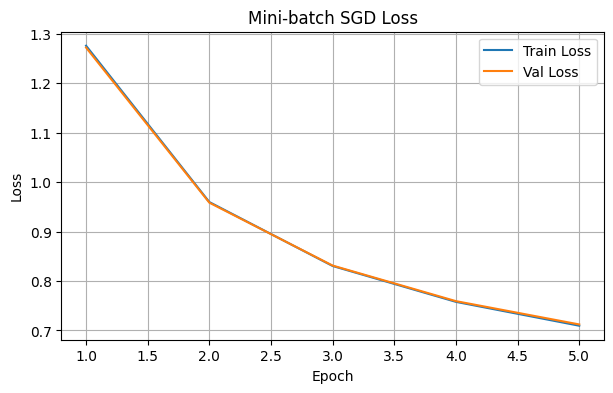

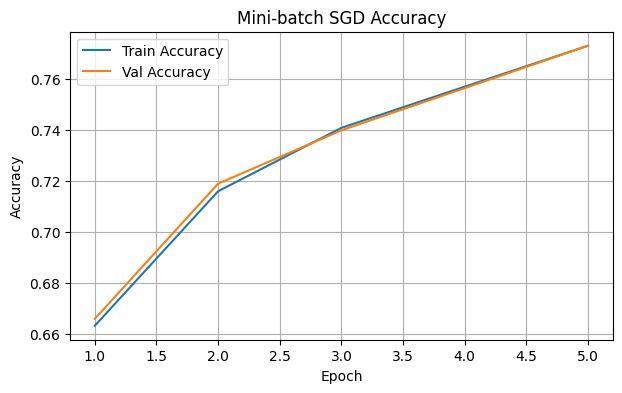

In [64]:
params_example, history_example = train_model(
    X_train, y_train, Y_train,
    X_val, y_val, Y_val,
    method="mini_batch_sgd",
    learning_rate=0.001,
    epochs=5,
    batch_size=64
)

plot_history(history_example, "Mini-batch SGD")

In [65]:
test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate_model(X_test, y_test, Y_test, params_example)

print("Test Loss         :", round(test_loss, 4))
print("Test Accuracy     :", round(test_acc, 4))
print("Macro Precision   :", round(test_prec, 4))
print("Macro Recall      :", round(test_rec, 4))
print("Macro F1-score    :", round(test_f1, 4))

Test Loss         : 0.7153
Test Accuracy     : 0.7691
Macro Precision   : 0.7685
Macro Recall      : 0.7691
Macro F1-score    : 0.7632


## Required Experiments

| Exp | Method | Learning Rate | Batch Size | Epochs |
|---|---|---:|---:|---:|
| 1 | GD | 0.001 | Full batch | 20 |
| 2 | GD | 0.001 | Full batch | 30 |
| 3 | GD | 0.01 | Full batch | 30 |
| 4 | SGD | 0.001 | 1 | 20 |
| 5 | SGD | 0.001 | 1 | 40 |
| 6 | Mini-batch SGD | 0.001 | 64 | 20 |
| 7 | Mini-batch SGD | 0.01 | 64 | 20 |
| 8 | Mini-batch SGD | 0.0001 | 64 | 20 |
| 9 | Mini-batch SGD | 0.001 | 16 | 20 |
| 10 | Mini-batch SGD | 0.001 | 256 | 20 |
| 11 | Mini-batch SGD | 0.001 | 64 | 5 |
| 12 | Mini-batch SGD | 0.001 | 64 | 50 |

Epoch 1: train_loss = 2.0597856082622994, val_loss = 2.053492321690676, train_acc = 0.27556, val_acc = 0.2893
Epoch 2: train_loss = 1.884880624337017, val_loss = 1.880159568719683, train_acc = 0.42408, val_acc = 0.4356
Epoch 3: train_loss = 1.745816813921089, val_loss = 1.7408694997328573, train_acc = 0.52712, val_acc = 0.5295
Epoch 4: train_loss = 1.6261966936089658, val_loss = 1.6219885809968146, train_acc = 0.56012, val_acc = 0.5707
Epoch 5: train_loss = 1.523608510933102, val_loss = 1.519164111946042, train_acc = 0.6016, val_acc = 0.6041
Epoch 6: train_loss = 1.4381492341110584, val_loss = 1.4344493294275336, train_acc = 0.61556, val_acc = 0.6192
Epoch 7: train_loss = 1.3759691279162802, val_loss = 1.3717385809578513, train_acc = 0.6126, val_acc = 0.6147
Epoch 8: train_loss = 1.3667776230700008, val_loss = 1.364570485632336, train_acc = 0.60912, val_acc = 0.6102
Epoch 9: train_loss = 1.3535499713549204, val_loss = 1.3500178605050994, train_acc = 0.568, val_acc = 0.5686
Epoch 10: tr

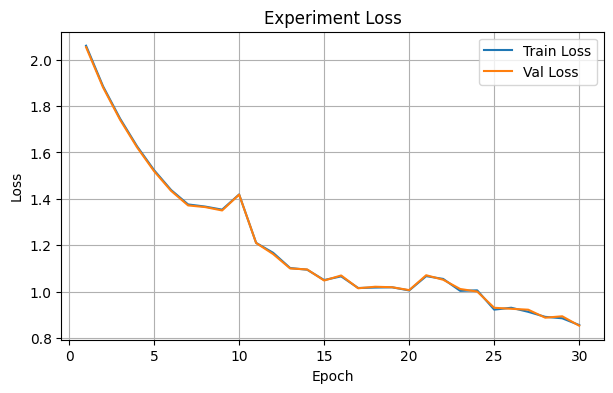

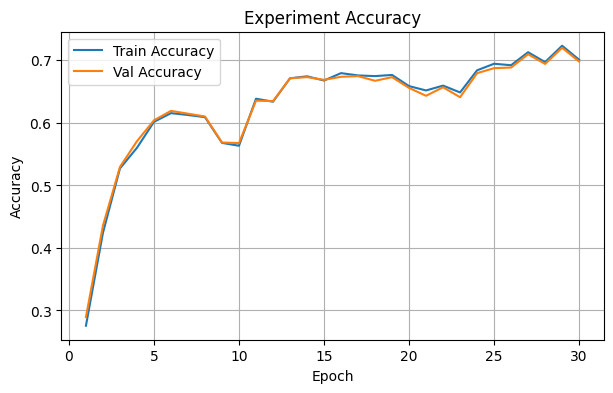

Final Test Results
Loss            : 0.8623
Accuracy        : 0.699
Macro Precision : 0.7444
Macro Recall    : 0.699
Macro F1-score  : 0.6785


In [66]:
# Change the settings below for each experiment

EXPERIMENT_NAME = "Experiment"
METHOD = "gd"              # "gd", "sgd", or "mini_batch_sgd"
LEARNING_RATE = 0.1
BATCH_SIZE = 64
EPOCHS = 30

params_exp, history_exp = train_model(
    X_train, y_train, Y_train,
    X_val, y_val, Y_val,
    method=METHOD,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

plot_history(history_exp, EXPERIMENT_NAME)

test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate_model(X_test, y_test, Y_test, params_exp)

print("Final Test Results")
print("Loss            :", round(test_loss, 4))
print("Accuracy        :", round(test_acc, 4))
print("Macro Precision :", round(test_prec, 4))
print("Macro Recall    :", round(test_rec, 4))
print("Macro F1-score  :", round(test_f1, 4))